# Semi-supervised GMM

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# from scipy.stats import norm
from scipy.stats import multivariate_normal
from scipy.fftpack import fft
from scipy.interpolate import make_splrep
from scipy.special import logsumexp

# from sklearn.mixture import GaussianMixture
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# from tslearn.preprocessing import TimeSeriesScalerMeanVariance
# from tslearn.utils import to_time_series_dataset
from tsfresh.feature_extraction import feature_calculators as feat_calc

import pyLasaDataset as lasa
# from hmmlearn import hmm
# from tqdm.auto import tqdm

Using LASA DataSet from /home/kir0ul/Projects/BayesDistanceClustering/.direnv/python-3.13/lib64/python3.13/site-packages/pyLasaDataset/resources/LASAHandwritingDataset/DataSet


### Hyperparameters

In [2]:
# seed = 0
seed = 42
seq_length = 1000
rng = np.random.default_rng(seed)
window_size = 20
window_step = 5

In [3]:
# max_iter = 300
# tol = 1e-6
beta = 0.5

## Data

In [4]:
# series1 = rng.normal(loc=0, scale=1, size=(seq_length, 2))
# series2 = rng.normal(loc=5, scale=1, size=(seq_length, 2))
# series3 = rng.normal(loc=-3, scale=1, size=(seq_length, 2))
# data = np.stack([series1, series2, series3])
# data.shape

In [5]:
means = np.array(
    [
        [1, 3],
        [3, 1],
        [2.5, 2.5],
    ]
)
covs = np.eye(2) * 0.08
data = np.ones((means.shape[0], seq_length, 2)) * np.nan
for idx in range(means.shape[0]):
    data[idx, :, :] = rng.multivariate_normal(
        mean=means[idx, :], cov=covs, size=(seq_length)
    )
data.shape

(3, 1000, 2)

In [6]:
K_components = data.shape[0]

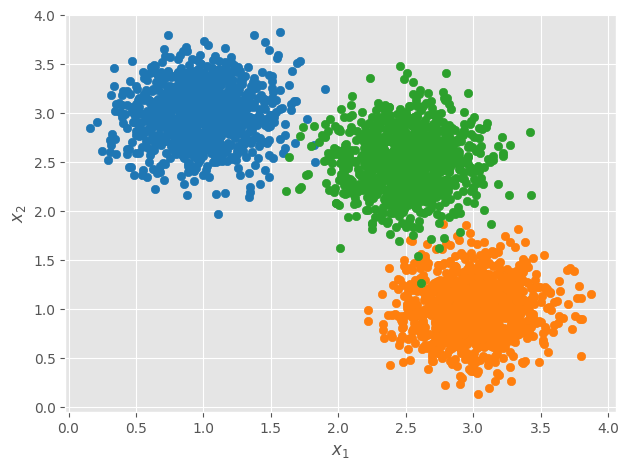

In [7]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(data.shape[0]):
        ax.scatter(data[idx, :, 0], data[idx, :, 1], color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

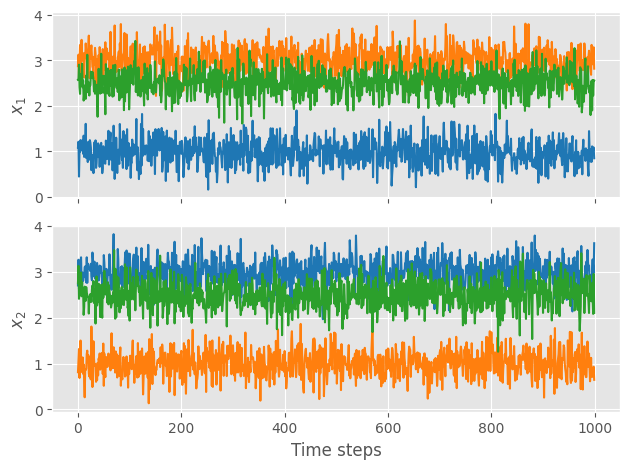

In [8]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(data.shape[-1], 1, sharex=True)
    for idx in range(data.shape[-1]):
        for jdx in range(data.shape[0]):
            ax[idx].plot(data[jdx, :, idx], c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

## Preprocessing & feature engineering

In [9]:
# dataset = to_time_series_dataset(data)
# dataset.shape

In [10]:
# scaler = TimeSeriesScalerMeanVariance()
# data_scaled = np.squeeze(scaler.fit_transform(data))
# data_scaled.shape

In [11]:
def sliding_window(series, window_size, step=1):
    windows = []
    for idx in range(0, len(series) - window_size + 1, step):
        windows.append(series[idx : idx + window_size])
    return np.array(windows)

In [12]:
windows = []
for idx in range(data.shape[0]):
    data_sc_i = data[idx, :, :]
    windows.append(
        sliding_window(series=data_sc_i, window_size=window_size, step=window_step)
    )
windows = np.array(windows)
windows.shape

(3, 197, 20, 2)

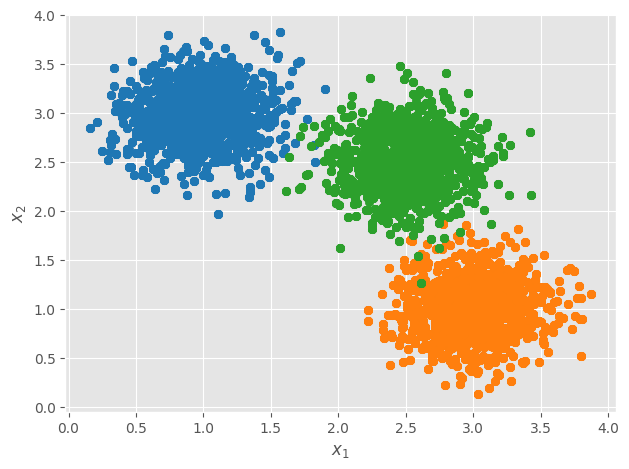

In [13]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        for jdx in range(windows.shape[1]):
            ax.scatter(
                windows[idx, jdx, :, 0], windows[idx, jdx, :, 1], color=cmap[idx]
            )
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

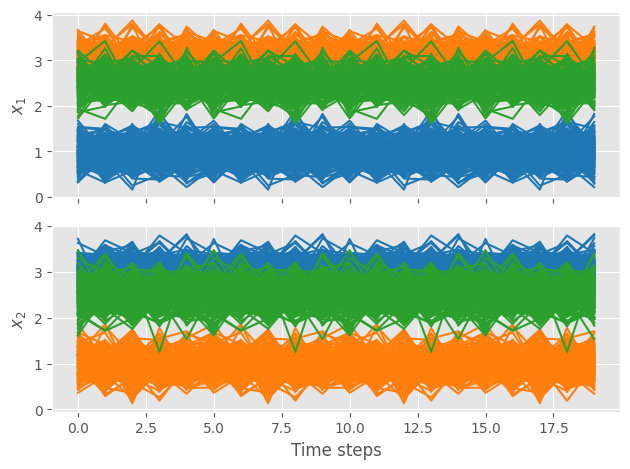

In [14]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[0]):
            for kdx in range(windows.shape[1]):
                ax[idx].plot(windows[jdx, kdx, :, idx], c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [15]:
def loop_on_col(arr, funct, *args, **kwargs):
    res = []
    for col in range(arr.shape[1]):
        res.append(funct(arr[:, col], *args, **kwargs))
    return res

In [16]:
def extract_features(windows, lag=5, bins=10):
    features = []
    for win in windows:
        feats = [
            # np.mean(win),
            # np.std(win),
            # np.min(win),
            # np.max(win),
            # np.median(win),
            # np.percentile(win, 25),
            # np.percentile(win, 75),
            # *np.abs(fft(win)).flatten()[:5]
            *loop_on_col(arr=win, funct=feat_calc.abs_energy),
            feat_calc.absolute_sum_of_changes(win),
            feat_calc.autocorrelation(x=win, lag=lag),
            *loop_on_col(arr=win, funct=feat_calc.benford_correlation),
            # feat_calc.binned_entropy(x=win, max_bins=bins),
            feat_calc.c3(x=win, lag=lag),
            *loop_on_col(arr=win, funct=feat_calc.cid_ce, normalize=True),
            # *loop_on_col(arr=win, funct=feat_calc.fourier_entropy, bins=bins),
            *loop_on_col(arr=win, funct=feat_calc.kurtosis),
            *loop_on_col(arr=win, funct=feat_calc.lempel_ziv_complexity, bins=bins),
            *loop_on_col(arr=win, funct=feat_calc.longest_strike_above_mean),
            *loop_on_col(arr=win, funct=feat_calc.longest_strike_below_mean),
            feat_calc.mean_abs_change(win),
            *feat_calc.mean_change(win),
            *feat_calc.mean_second_derivative_central(win),
            *loop_on_col(
                arr=win,
                funct=feat_calc.percentage_of_reoccurring_datapoints_to_all_datapoints,
            ),
            *loop_on_col(
                arr=win, funct=feat_calc.percentage_of_reoccurring_values_to_all_values
            ),
            feat_calc.ratio_value_number_to_time_series_length(win),
            feat_calc.root_mean_square(win),
            feat_calc.sample_entropy(win),
            *loop_on_col(arr=win, funct=feat_calc.skewness),
            feat_calc.time_reversal_asymmetry_statistic(x=win, lag=lag),
            feat_calc.variation_coefficient(win),
            # ToDo: add curvature feature
        ]
        features.append(feats)
    return np.array(features)

In [17]:
features = []
for idx in range(windows.shape[0]):
    window_i = windows[idx, :, :]
    features.append(extract_features(window_i))
features = np.array(features)
features.shape

(3, 197, 33)

In [18]:
labels_gt = (
    np.array([np.ones(features.shape[1]) * idx for idx in range(features.shape[0])])
    .flatten()
    .astype(int)
)
labels_gt

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [19]:
labels_gt = (
    np.array([np.ones(data.shape[1]) * idx for idx in range(data.shape[0])])
    .flatten()
    .astype(int)
)
labels_gt

array([0, 0, 0, ..., 2, 2, 2], shape=(3000,))

In [20]:
feat_mat = features.reshape(features.shape[0] * features.shape[1], features.shape[2])
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,23.837083,175.534125,37.753460,1.868062,0.757353,0.306583,13.465137,7.015794,7.139521,2.211940,...,0.0,0.0,0.0,1.0,2.232550,0.813929,-0.386215,0.389880,0.409550,0.482382
1,25.088046,181.755020,38.128640,1.904581,0.765196,0.251848,14.257476,7.348869,6.469934,0.732647,...,0.0,0.0,0.0,1.0,2.274000,0.741937,0.412449,0.014447,0.340687,0.472581
2,22.118955,185.360813,40.260864,1.870729,0.614560,0.230027,14.553801,6.487957,6.554335,0.533683,...,0.0,0.0,0.0,1.0,2.277497,0.635388,0.482092,0.242589,0.951359,0.505755
3,21.234649,186.720904,41.006547,1.947816,0.642764,0.230027,14.633701,5.827306,6.966480,0.410811,...,0.0,0.0,0.0,1.0,2.280107,0.665597,0.224241,0.171653,0.168353,0.517790
4,19.217989,186.945565,41.952843,1.969013,0.669453,0.206645,14.622910,5.984406,6.321674,-0.969778,...,0.0,0.0,0.0,1.0,2.270262,0.642793,-0.372318,-0.066416,-0.798873,0.532666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586,120.229843,127.352359,9.153946,0.134050,0.467821,0.406869,14.942868,6.064971,5.291377,-0.112080,...,0.0,0.0,0.0,1.0,2.487882,0.405465,0.378658,0.184188,-0.635733,0.149153
587,121.059587,128.146113,8.552917,0.021100,0.467821,0.406869,15.152124,5.507643,5.392312,-1.062244,...,0.0,0.0,0.0,1.0,2.496025,0.245122,0.026526,0.105391,0.679066,0.145990
588,124.833965,126.215339,8.159748,0.014328,0.467821,0.406869,15.274564,5.392272,5.055243,-0.884522,...,0.0,0.0,0.0,1.0,2.505241,0.328504,-0.139638,0.232566,1.019156,0.143158
589,117.232516,132.415259,7.160363,-0.200442,0.467821,0.295657,15.182778,5.171043,6.505539,0.124016,...,0.0,0.0,0.0,1.0,2.498238,0.245122,0.108936,-0.295204,-0.689080,0.116712


In [21]:
feat_mat = data.reshape(data.shape[0] * data.shape[1], data.shape[2])
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1
0,1.086187,2.705848
1,1.212260,3.266032
2,0.448164,2.631688
3,1.036159,2.910553
4,0.995248,2.758723
...,...,...
2995,1.899277,2.760851
2996,2.568736,2.411204
2997,2.226722,2.084262
2998,2.563326,2.956350


In [22]:
# scaler = StandardScaler()
# feat_mat = scaler.fit_transform(feat_mat)
# feat_mat = pd.DataFrame(feat_mat)
# feat_mat

### Supervised data

In [23]:
# supervised_sample_size = 10
# idx_superv = np.random.choice(
#     np.arange(labels_gt.shape[0]), size=supervised_sample_size, replace=False
# )
# Y = np.zeros((len(idx_superv), K_components))
# for idxi, idx_val in enumerate(idx_superv):
#     Y[idxi, int(labels_gt[int(idx_val)])] = 1
# # Y = labels_gt[idx_superv]
# X = feat_mat.iloc[idx_superv, :]
# X.shape, Y

In [24]:
def select_supervised_data(total_sample_size, labels_gt, K_components, U):
    unique_labels = np.unique(labels_gt)
    label_sample_size = int(np.round(total_sample_size / len(unique_labels)))

    # Select balanced data for each label
    all_idx = np.arange(labels_gt.shape[0])
    idx_superv = []
    for label in unique_labels:
        current_label_mask = labels_gt == label
        current_label_idx = np.array(
            [idx for idx in all_idx if current_label_mask[idx] == True]
        )
        assert len(current_label_idx) >= label_sample_size, (
            f"Not enough data points to select {label_sample_size} samples for class {label}, only {len(current_label_idx)} found"
        )
        idx_superv.extend(
            np.random.choice(current_label_idx, size=label_sample_size, replace=False)
        )
    idx_superv = np.array(idx_superv)

    # Build the Y matrix
    Y = np.zeros((len(idx_superv), K_components))
    for idxi, idx_val in enumerate(idx_superv):
        Y[idxi, int(labels_gt[int(idx_val)])] = 1

    X = U[idx_superv, :]
    return X, Y

In [25]:
supervised_sample_size = 10
X, Y = select_supervised_data(
    total_sample_size=supervised_sample_size,
    labels_gt=labels_gt,
    K_components=K_components,
    U=feat_mat.to_numpy(),
)
X.shape, Y

((9, 2),
 array([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.]]))

## GMM clustering

In [26]:
def e_step(U, pi_mixing_prior, mu, Sigma, seed=None, allow_singular=False):
    """
    Compute the expectation step (equation 4).

    U: unlabeled training data
    """
    N = U.shape[0]
    K = pi_mixing_prior.shape[0]
    log_probs = np.zeros((N, K))

    for n in range(N):
        for k in range(K):
            log_probs[n, k] = np.log(pi_mixing_prior[k]) + multivariate_normal.logpdf(
                x=U[n, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
            )
    log_norm = logsumexp(log_probs, axis=1, keepdims=True)
    gamma_resp = np.exp(log_probs - log_norm)
    return gamma_resp

In [27]:
def m_step(U, X, Y, gamma_resp, beta=0.5, reg_coef=1e-3):
    """
    Compute the maximization step.
    """
    assert X.shape[0] == Y.shape[0], "X and Y must have the same number of rows"
    assert U.shape[1] == X.shape[1], "U and X must have the same number of columns"
    M, D = X.shape
    N, _ = U.shape
    K = gamma_resp.shape[1]

    pi_mixing_prior_new = np.zeros(K) * np.nan
    mu_new = np.zeros((K, D)) * np.nan
    Sigma_new = np.zeros((K, D, D)) * np.nan

    for k in range(K):
        common_term = (1 - beta) * gamma_resp.sum(axis=0)[k] + beta * Y.sum(axis=0)[k]

        # Update mixing coefficients (equation 5)
        pi_mixing_prior_new[k] = common_term / ((1 - beta) * N + beta * M)

        # Update means (equation 6)
        gamma_resp_u = 0
        gamma_resp_x = 0
        for n in range(N):
            gamma_resp_u += gamma_resp[n, k] * U[n, :]
        for m in range(M):
            gamma_resp_x += gamma_resp[m, k] * X[m, :]
        mu_new[k, :] = ((1 - beta) * gamma_resp_u + beta * gamma_resp_x) / common_term

        # Update covariances (equation 7)
        gamma_resp_u_mu = 0
        gamma_resp_x_mu = 0
        for n in range(N):
            gamma_resp_u_mu += (
                gamma_resp[n, k] * (U[n, :] - mu_new[k]) * (U[n, :] - mu_new[k]).T
            )
        for m in range(M):
            gamma_resp_x_mu += (
                gamma_resp[n, k] * (X[m, :] - mu_new[k]) * (X[m, :] - mu_new[k]).T
            )
        # Sigma_new[k] = ((1 - beta) * gamma_resp_u_mu) / common_term + (
        #     beta * gamma_resp_x_mu
        # ) / common_term
        var = ((1 - beta) * gamma_resp_u_mu) / common_term + (
            beta * gamma_resp_x_mu
        ) / common_term
        # var = 1/2*(var + var.T)  # Semi Positive Definite issue
        # # regularization for numerical stability (optional, small jitter)
        # Sigma_new[k] += reg_coef*np.eye(D)

        # # Constrain the covariance matrices to be diagonal
        # var = (gamma_resp[:, k][:, None] * diff**2).sum(axis=0) / Nk[k]
        Sigma_new[k] = np.diag(var + reg_coef)
    return pi_mixing_prior_new, mu_new, Sigma_new

In [28]:
def log_likelihood(U, X, Y, pi_mixing_prior, mu, Sigma, beta=0.5, allow_singular=False):
    """
    Compute the log-likelihood (equation 9).
    """
    assert X.shape[0] == Y.shape[0], "X and Y must have the same number of rows"
    assert U.shape[1] == X.shape[1], "U and X must have the same number of columns"
    M, D = X.shape
    N, _ = U.shape
    K = pi_mixing_prior.shape[0]
    log_probs = np.zeros((N, K))
    log_lik_unsuperv = np.zeros((N, K))
    log_lik_superv = np.zeros((N, K))

    for n in range(N):
        for k in range(K):
            log_probs[n, k] = np.log(pi_mixing_prior[k]) + multivariate_normal.logpdf(
                x=U[n, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
            )
    log_norm = logsumexp(log_probs, axis=1, keepdims=True)
    log_lik_unsuperv = (1 - beta) * log_norm.sum(axis=0)

    for m in range(M):
        for k in range(K):
            # ToDo: may need to convert the multiplication by `Y[m, k]` to a sum of log
            log_lik_superv[m, k] = Y[m, k] * np.log(
                pi_mixing_prior[k]
            ) + multivariate_normal.logpdf(
                x=X[m, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
            )
    log_lik_superv = beta * log_lik_superv.sum()

    return log_lik_unsuperv + log_lik_superv

In [29]:
def run_EM(
    K_components,
    U,
    X,
    Y,
    beta=0.5,
    reg_coef=1e-3,
    max_iter=300,
    tol=1e-6,
    seed=None,
    allow_singular=False,
):
    """
    Expectation-Maximization algorithm.

    Implemented from [1].

    [1] Yan, H.-C., Zhou, J.-H., & Pang, C. K. (2017).
    Gaussian Mixture Model Using Semisupervised Learning for Probabilistic Fault Diagnosis Under New Data Categories.
    IEEE Transactions on Instrumentation and Measurement, 66(4), 723–733.
    https://doi.org/10.1109/TIM.2017.2654552

    """

    # Initialization
    N, D = X.shape
    pi_mixing_prior = np.ones(K_components) / K_components
    # pi_mixing_prior = np.random.uniform(size=K_components)
    # pi_mixing_prior = pi_mixing_prior/pi_mixing_prior.sum()
    # mu = np.random.rand(K_components, D) * 10.0
    kmeans_init = KMeans(n_clusters=K_components, random_state=seed).fit(X=X)
    mu = np.array(kmeans_init.cluster_centers_)
    # Sigma = np.array([np.eye(D) * rng.uniform(low=0, high=0.01, size=D) for _ in range(K_components)])
    Sigma = np.array([np.eye(D) for _ in range(K_components)])

    lls = []
    for it in range(max_iter):
        # E-step
        gamma_resp = e_step(
            U=U, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma, seed=seed
        )

        # M-step
        pi_mixing_prior, mu, Sigma = m_step(
            U=U, X=X, Y=Y, gamma_resp=gamma_resp, reg_coef=reg_coef
        )

        # Log-likelihood
        ll = log_likelihood(
            U=U,
            X=X,
            Y=Y,
            pi_mixing_prior=pi_mixing_prior,
            mu=mu,
            Sigma=Sigma,
            allow_singular=allow_singular,
        )
        lls.append(ll)

        # Logging during training
        if it % 10 == 0:
            # plot_gmm(X, mu, Sigma, title=f'GMM Contours — Iteration {it+1}')
            print(f"Iteration {it}/{max_iter} -- Log-likelihood: {ll[0]}")

        # Convergence check
        if it > 0 and abs(lls[-1] - lls[-2]) < tol:
            print(f"\n--- Converged at iteration {it + 1} ---\n")
            break

    with plt.style.context("ggplot"):
        fig, ax = plt.subplots()
        ax.plot(lls, marker=".", c="k")
        ax.set_title("EM training")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Log-likelihood")
        # ax.set_grid(True, alpha=0.3)
        plt.show()

    labels_pred = np.argmax(gamma_resp, axis=1)
    return mu, Sigma, gamma_resp, labels_pred, pi_mixing_prior

In [30]:
def predict(U, pi_mixing_prior, mu, Sigma, seed=None):
    gamma_resp = e_step(
        U=U, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma, seed=seed
    )
    labels_pred = np.argmax(gamma_resp, axis=1)
    return gamma_resp, labels_pred

Iteration 0/300 -- Log-likelihood: -3134.8115847751346
Iteration 10/300 -- Log-likelihood: -2347.1563521911394
Iteration 20/300 -- Log-likelihood: -2349.3924159876233

--- Converged at iteration 23 ---



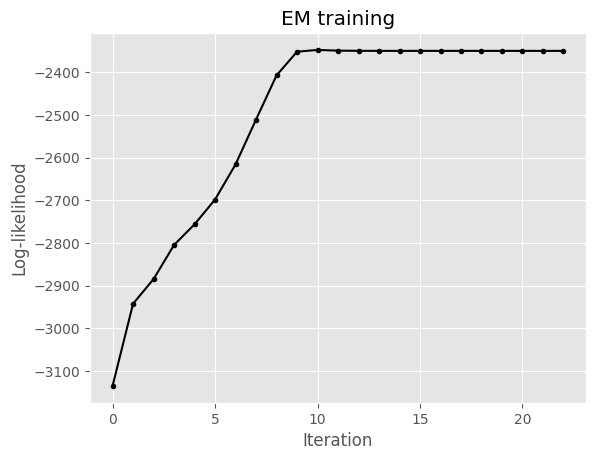

In [31]:
reg_coef = 1e-5
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X,
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    seed=seed,
    allow_singular=False,
)

In [32]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[2.50036304, 2.49232308],
        [0.99579006, 2.99881261],
        [2.9951607 , 1.00039019]]),
 array([[[0.08300504, 0.        ],
         [0.        , 0.09667119]],
 
        [[0.07834026, 0.        ],
         [0.        , 0.08184339]],
 
        [[0.07905404, 0.        ],
         [0.        , 0.07843235]]]),
 array([[7.38805606e-06, 9.99992612e-01, 1.56483869e-18],
        [3.85930517e-06, 9.99996141e-01, 2.41586987e-23],
        [1.20234977e-10, 1.00000000e+00, 1.02051612e-24],
        ...,
        [9.99942228e-01, 1.57914335e-06, 5.61931565e-05],
        [9.99999468e-01, 5.31992516e-07, 2.77997680e-11],
        [9.99708482e-01, 3.34911988e-09, 2.91514960e-04]], shape=(3000, 3)),
 array([1, 1, 1, ..., 0, 0, 0], shape=(3000,)),
 array([0.33407384, 0.33318193, 0.33274423]))

In [33]:
# with plt.style.context("ggplot"):
#     cmap = plt.colormaps["tab10"].colors
#     fig, ax = plt.subplots()
#     for idx in range(data.shape[0]):
#         ax.scatter(data[idx, :, 0], data[idx, :, 1], color="k", alpha=0.4)
#     ax.set_xlabel(f"$x_1$")
#     ax.set_ylabel(f"$x_2$")

#     # xg, yg = np.meshgrid(np.linspace(-5, 15, 100), np.linspace(-5, 15, 100))
#     # pos = np.dstack((xg, yg))
#     # for jdx in range(K_components):
#     #     rv = rng.multivariate_normal(
#     #         mean=gmm.means_[jdx], cov=gmm.covariances_[jdx]
#     #     )
#     #     # ax.contour(xg, yg, rv.pdf(pos), levels=5, colors=cmap[jdx], alpha=0.8)
#     #     ax.scatter(gmm.means_[jdx, 0], gmm.means_[jdx, 1], c="k")#, color=cmap[jdx], marker="x", s=100)

#     fig.tight_layout()
#     plt.show()

### Metrics

In [34]:
# accu = accuracy_score(y_true=labels_gt, y_pred=clust_labels_pred)
# print(f"Accuracy: {accu}")

In [35]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=labels_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=labels_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=labels_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=labels_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=labels_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=labels_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=labels_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=labels_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=labels_gt, labels_pred=clust_labels_pred)}"
)

Silhouette: 0.6700492608739216
Completeness: 0.9735006284196557
Fowlkes-Mallows index: 0.9913590285756212
Homogeneity: 0.9735003330467866
Mutual Information: 1.0694994289076967
Adjusted mutual information: 0.973484376029936
Normalized Mutual Information: 0.9735004807331988
Rand index: 0.9942431921751695
Adjusted rand index: 0.9870428611895389
V-measure: 0.9735004807331987


In [36]:
def plot_cluster_res(U, X, Y, labels_gt, labels_pred, gamma_resp, mu):

    # Transform data to first two principal components for plotting
    pca = PCA(n_components=2)
    U_pca = pca.fit_transform(U)
    X_pca = pca.transform(X)
    mu_pca = pca.transform(mu)

    uncertainty = 1 - gamma_resp.max(axis=1)

    with plt.style.context("ggplot"):
        fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
        ax[0].scatter(U_pca[:, 0], U_pca[:, 1], c=labels_gt, alpha=0.5, s=20)
        ax[0].scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            marker="+",
            c="k",
            alpha=0.5,
            s=20,
            label="Supervised data",
        )
        ax[0].set_title("True clusters")
        ax[1].scatter(U_pca[:, 0], U_pca[:, 1], c=labels_pred, alpha=0.5, s=20)
        ax[1].scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            marker="+",
            c="k",
            alpha=0.5,
            s=20,
            label="Supervised data",
        )
        ax[1].scatter(
            mu_pca[:, 0],
            mu_pca[:, 1],
            marker="x",
            c="r",
            alpha=1,
            s=50,
            label=r"$\mu$",
        )
        ax[1].set_title("Predicted clusters")
        ax[2].scatter(U_pca[:, 0], U_pca[:, 1], c=uncertainty, alpha=0.5, s=20)
        ax[2].set_title("Uncertainty")
        for axi in ax:
            axi.set_xlabel("PC 1")
            axi.set_ylabel("PC 2")
        for axi in ax[:2]:
            axi.legend(
                loc="best", facecolor="white"
            )  # , edgecolor='black', fancybox=True)
        fig.tight_layout()
        plt.show()

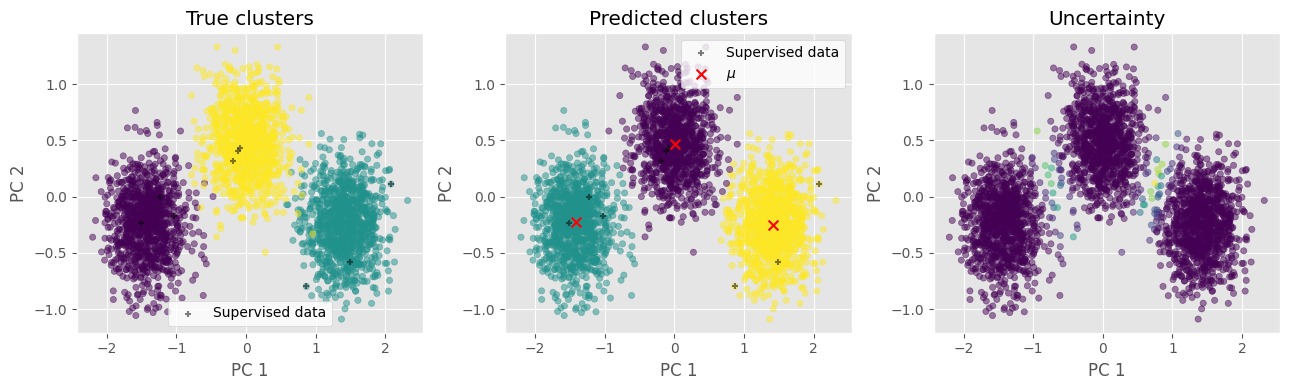

In [37]:
plot_cluster_res(
    U=feat_mat,
    X=X,
    Y=Y,
    labels_gt=labels_gt,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

### New data

In [38]:
# new_data = np.random.normal(6, 1, 70)
# new_feat = np.array([np.mean(new_data), np.std(new_data)])[np.newaxis, :]
# new_feat

In [39]:
new_data = rng.multivariate_normal(
    mean=np.array([6, 1]), cov=covs, size=(seq_length * 2)
)
new_data.shape

(2000, 2)

In [40]:
# new_data_scaled = np.squeeze(scaler.transform(new_data))
# new_data_scaled.shape

In [41]:
new_windows = sliding_window(series=new_data, window_size=window_size, step=window_step)
new_windows.shape

(397, 20, 2)

In [42]:
new_feat_mat = pd.DataFrame(extract_features(new_windows))
new_feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,711.609077,20.097114,99.881163,2.012049,-0.255874,0.747516,106.357234,6.316146,6.580340,1.047133,...,0.0,0.0,0.0,1.0,4.276991,0.440469,-0.867716,-0.574049,2.158741,0.726340
1,733.013564,18.767848,102.315755,1.945320,-0.264237,0.556063,110.826907,6.945424,6.577710,-0.644194,...,0.0,0.0,0.0,1.0,4.335266,0.358846,-0.147830,-0.298531,3.981280,0.737167
2,722.037704,21.382749,100.242953,1.986181,-0.247033,0.613523,108.491665,6.840125,6.576602,-0.015051,...,0.0,0.0,0.0,1.0,4.311092,0.366499,0.504420,-0.150523,0.888973,0.720979
3,726.977143,22.683289,99.740560,1.978863,-0.255874,0.619339,109.649285,6.669201,6.489445,-0.553761,...,0.0,0.0,0.0,1.0,4.329147,0.308069,0.474487,0.278492,-5.713013,0.710315
4,739.514218,18.383036,103.184614,1.901588,-0.264237,0.508617,112.216097,5.408276,6.282942,-1.027163,...,0.0,0.0,0.0,1.0,4.352865,0.336961,0.286441,0.055208,4.256850,0.743525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,708.208189,26.108161,96.845925,1.994440,-0.255874,0.773054,105.384020,7.554924,5.184554,0.314715,...,0.0,0.0,0.0,1.0,4.284613,0.312208,-0.533451,-0.111208,-3.412260,0.693208
393,705.455347,23.865997,97.604205,1.954537,-0.255874,0.632493,104.769470,7.633597,5.742645,0.890713,...,0.0,0.0,0.0,1.0,4.270016,0.370618,-1.121521,0.151842,2.075531,0.703512
394,714.212118,21.877264,99.512451,1.912847,-0.255874,0.409042,106.694551,7.762871,5.614745,1.673300,...,0.0,0.0,0.0,1.0,4.289783,0.375833,-1.244687,0.310525,5.060072,0.719922
395,719.566927,25.777082,98.121548,2.019137,-0.255874,0.757678,108.104399,6.970014,5.943792,2.791837,...,0.0,0.0,0.0,1.0,4.316665,0.388897,-1.350412,-0.394144,2.196683,0.698008


In [43]:
new_feat_mat = pd.DataFrame(new_data)
new_feat_mat

,0,1
0,6.063673,0.984912
1,6.244388,1.171610
2,5.155482,1.154218
3,5.716173,0.597874
4,5.946692,1.116240
...,...,...
1995,6.120215,0.480361
1996,5.850508,1.196963
1997,5.822630,1.458235
1998,5.982130,1.024112


In [44]:
# new_feat_scaled = scaler.fit_transform(new_feat)
# new_feat_scaled = pd.DataFrame(new_feat_scaled)
# new_feat_scaled

In [45]:
feat_mat_concat = pd.concat((feat_mat, new_feat_mat))
feat_mat_concat

,0,1
0,1.086187,2.705848
1,1.212260,3.266032
2,0.448164,2.631688
3,1.036159,2.910553
4,0.995248,2.758723
...,...,...
1995,6.120215,0.480361
1996,5.850508,1.196963
1997,5.822630,1.458235
1998,5.982130,1.024112


In [46]:
labels_gt_new = np.ones(new_data.shape[0]).astype(int) * 3
labels_gt_new

array([3, 3, 3, ..., 3, 3, 3], shape=(2000,))

In [47]:
labels_gt_concat = np.concat((labels_gt, labels_gt_new), axis=0)
labels_gt_concat

array([0, 0, 0, ..., 3, 3, 3], shape=(5000,))

In [48]:
gamma_resp, labels_pred = predict(
    U=feat_mat_concat.to_numpy(),
    pi_mixing_prior=pi_mixing_prior,
    mu=mu,
    Sigma=Sigma,
    seed=seed,
)
gamma_resp, labels_pred

(array([[7.38805674e-06, 9.99992612e-01, 1.56483923e-18],
        [3.85930535e-06, 9.99996141e-01, 2.41587122e-23],
        [1.20234998e-10, 1.00000000e+00, 1.02051648e-24],
        ...,
        [1.61804151e-09, 4.53638837e-49, 9.99999998e-01],
        [7.91431292e-13, 1.72927421e-55, 1.00000000e+00],
        [6.28990687e-14, 4.53709168e-60, 1.00000000e+00]], shape=(5000, 3)),
 array([1, 1, 1, ..., 2, 2, 2], shape=(5000,)))

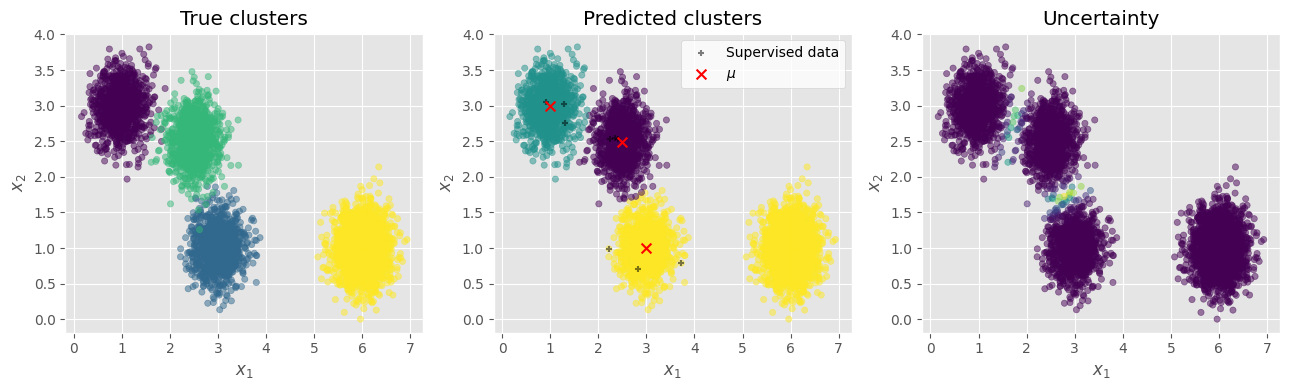

In [49]:
# # Transform data to first two principal components for plotting
# pca = PCA(n_components=2)
# U_pca = pca.fit_transform(new_feat_mat.to_numpy())
# X_pca = pca.transform(feat_mat.to_numpy())
# mu_pca = pca.transform(mu)

U = feat_mat_concat.to_numpy()
uncertainty = 1 - gamma_resp.max(axis=1)

with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
    ax[0].scatter(U[:, 0], U[:, 1], alpha=0.5, s=20, c=labels_gt_concat)
    # ax[0].scatter(
    #     X[:, 0],
    #     X[:, 1],
    #     marker="+",
    #     c="k",
    #     alpha=0.5,
    #     s=20,
    #     label="Supervised data",
    # )
    ax[0].set_title("True clusters")
    ax[1].scatter(U[:, 0], U[:, 1], alpha=0.5, s=20, c=labels_pred)
    ax[1].scatter(
        X[:, 0],
        X[:, 1],
        marker="+",
        c="k",
        alpha=0.5,
        s=20,
        label="Supervised data",
    )
    ax[1].scatter(
        mu[:, 0],
        mu[:, 1],
        marker="x",
        c="r",
        alpha=1,
        s=50,
        label=r"$\mu$",
    )
    ax[1].set_title("Predicted clusters")
    ax[2].scatter(U[:, 0], U[:, 1], alpha=0.5, s=20, c=uncertainty)
    ax[2].set_title("Uncertainty")
    for axi in ax:
        # axi.set_xlabel("PC 1")
        # axi.set_ylabel("PC 2")
        axi.set_xlabel(f"$x_1$")
        axi.set_ylabel(f"$x_2$")
    # for axi in ax[:2]:
    ax[1].legend(loc="best", facecolor="white")
    fig.tight_layout()
    plt.show()

In [50]:
# from tslearn.preprocessing import TimeSeriesScalerMeanVariance
# from tslearn.clustering import TimeSeriesKMeans
# from tslearn.utils import to_time_series_dataset

# np.random.seed(0)
# time = np.linspace(0, 10, 50)
# series = [np.sin(time + shift) for shift in np.linspace(0, 3, 10)]
# dataset = to_time_series_dataset(series)

# scaler = TimeSeriesScalerMeanVariance()
# dataset_scaled = scaler.fit_transform(dataset)

# model = TimeSeriesKMeans(n_clusters=3, metric="dtw", random_state=0)
# labels = model.fit_predict(dataset_scaled)

# print("Cluster Labels (Shape-Based):", labels)

## Lasa

In [51]:
resample_num = 2**10
print(f"Resampling to {resample_num} data points")
smoothing_factor = 0

Resampling to 1024 data points


In [52]:
def smooth_arr(arr, nb_points=256, smoothing_factor=0):
    index_ori = np.arange(start=0, stop=arr.shape[0])
    new_index = np.linspace(start=0, stop=arr.shape[0], num=nb_points)
    arr_smooth = make_splrep(x=index_ori, y=arr, s=smoothing_factor)(new_index)
    return arr_smooth

In [53]:
datasets = [lasa.DataSet.heee, lasa.DataSet.Line, lasa.DataSet.Saeghe]
X = None
labels_gt = None
for idx, data in enumerate(datasets):
    # dt = data.dt
    demos = data.demos
    demo_id = 0
    demo = demos[demo_id]
    pos = demo.pos.T
    pos_resampled = smooth_arr(
        arr=pos, nb_points=resample_num, smoothing_factor=smoothing_factor
    )
    # pos_resampled = pos
    if X is None:
        X = np.hstack((np.arange(pos_resampled.shape[0])[:, np.newaxis], pos_resampled))
        labels_gt = np.ones((pos_resampled.shape[0],), dtype=int) * idx
    else:
        # dist_from_last_point = np.abs(X[-1, :] - pos_resampled[0, :])
        pos_with_time = np.hstack(
            (np.arange(pos_resampled.shape[0])[:, np.newaxis], pos_resampled)
        )
        # X = np.vstack((X, pos_resampled - dist_from_last_point))
        X = np.vstack((X, pos_with_time))
        labels_gt = np.hstack(
            (labels_gt, np.ones(pos_resampled.shape[0], dtype=int) * idx)
        )
# X = np.hstack((np.arange(X.shape[0])[:, np.newaxis], X))
print(X.shape)
print(labels_gt.shape)
dataset = pd.DataFrame(
    {
        "t": X[:, 0],
        "pos_x": X[:, 1],
        "pos_y": X[:, 2],
        "y_cls": labels_gt,
    }
)
dataset

(3072, 3)
(3072,)


,t,pos_x,pos_y,y_cls
0,0.0,-31.414643,18.078238,0
1,1.0,-31.414425,18.078527,0
2,2.0,-31.413891,18.079220,0
3,3.0,-31.413022,18.080319,0
4,4.0,-31.411800,18.081830,0
...,...,...,...,...
3067,1019.0,0.001816,0.001816,2
3068,1020.0,0.000857,0.000857,2
3069,1021.0,0.000250,0.000250,2
3070,1022.0,-0.000002,-0.000002,2


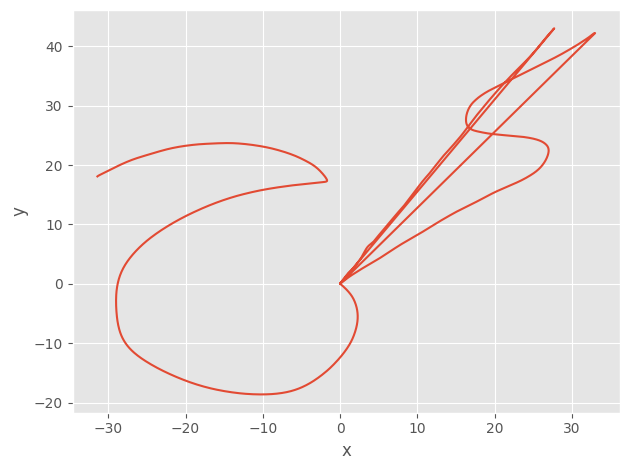

In [54]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots()
    ax.plot(dataset.pos_x, dataset.pos_y)  # , c=blobs[1], alpha=0.5, s=20)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.tight_layout()
    plt.show()

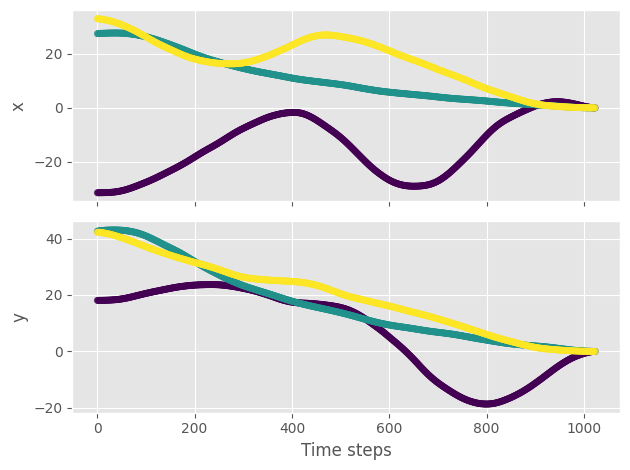

In [55]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(2, 1, sharex=True)
    ax[0].scatter(dataset.t, dataset.pos_x, c=dataset.y_cls, alpha=0.5, s=20)
    ax[1].scatter(dataset.t, dataset.pos_y, c=dataset.y_cls, alpha=0.5, s=20)
    ax[0].set_ylabel("x")
    ax[1].set_ylabel("y")
    ax[1].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [56]:
dataset[["pos_x", "pos_y"]]

,pos_x,pos_y
0,-31.414643,18.078238
1,-31.414425,18.078527
2,-31.413891,18.079220
3,-31.413022,18.080319
4,-31.411800,18.081830
...,...,...
3067,0.001816,0.001816
3068,0.000857,0.000857
3069,0.000250,0.000250
3070,-0.000002,-0.000002


In [57]:
# scaler = TimeSeriesScalerMeanVariance()
# ds_scaled = np.squeeze(scaler.fit_transform(dataset[["pos_x", "pos_y"]]))
# ds_scaled.shape

In [58]:
windows = sliding_window(
    series=dataset[["pos_x", "pos_y"]], window_size=window_size, step=window_step
)
windows.shape

(611, 20, 2)

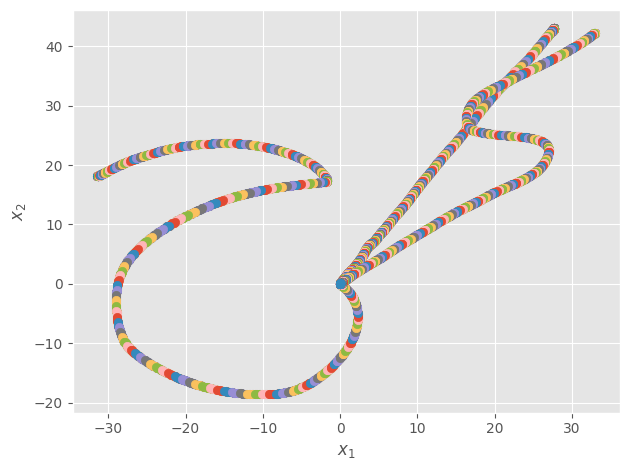

In [59]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        ax.scatter(windows[idx, :, 0], windows[idx, :, 1])  # , color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

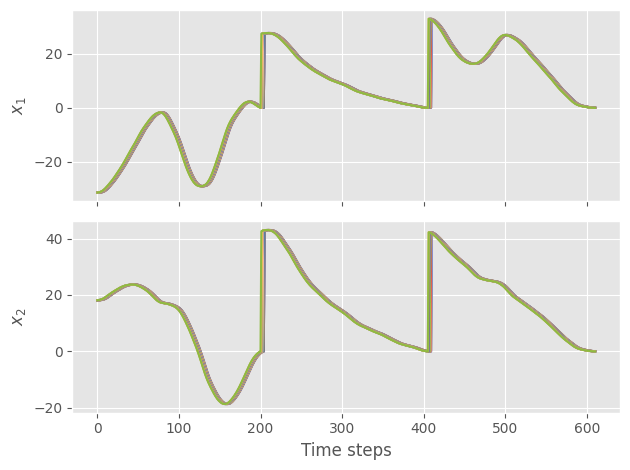

In [60]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[1]):
            ax[idx].plot(windows[:, jdx, idx])  # , c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [61]:
feat_mat = extract_features(windows)
feat_mat.shape

(611, 33)

In [62]:
for col in range(feat_mat.shape[1]):
    if np.any(np.isnan(feat_mat[:, col])):
        feat_mat = np.delete(arr=feat_mat, obj=col, axis=1)
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,19710.185086,6553.995510,9.899057e+02,2.000005,0.062915,0.864123,-12502.864336,0.810635,0.787044,-0.983799,...,0.0,0.0,0.0,1.0,25.624295,0.109637,0.579770,0.502830,44.651903,-3.724154
1,19684.603405,6568.927752,9.899100e+02,2.000029,0.062915,0.864123,-12462.608224,0.824128,0.787072,-0.840964,...,0.0,0.0,0.0,1.0,25.619100,0.109637,0.490137,0.339678,62.937180,-3.735692
2,19645.857839,6589.424174,9.898566e+02,2.000069,0.062915,0.864123,-12403.086448,0.837722,0.801492,-0.764577,...,0.0,0.0,0.0,1.0,25.610194,0.109637,0.587807,0.407010,88.333756,-3.752242
3,19590.080828,6616.078284,9.896985e+02,2.000105,0.062915,0.864123,-12319.365978,0.818766,0.793377,-0.856221,...,0.0,0.0,0.0,1.0,25.595976,0.109637,0.560341,0.419324,127.921645,-3.774886
4,19510.215652,6651.133298,9.893815e+02,2.000130,0.062915,0.864123,-12201.687448,0.804125,0.787087,-0.938412,...,0.0,0.0,0.0,1.0,25.574083,0.109637,0.491801,0.390800,179.918478,-3.806204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,0.285852,0.285852,1.738956e-13,0.744907,0.731806,0.731806,0.001393,0.759377,0.759377,-1.181497,...,0.0,0.0,0.0,1.0,0.119552,0.062132,0.163227,0.163227,-0.001618,0.303686
607,0.167250,0.167250,1.375358e-13,0.743562,0.635832,0.635832,0.000578,0.760394,0.760394,-1.173268,...,0.0,0.0,0.0,1.0,0.091447,0.068993,0.202042,0.202042,-0.000820,0.356909
608,0.089529,0.089529,1.476874e-13,0.740192,0.271055,0.271055,0.000200,0.769863,0.769863,-1.140704,...,0.0,0.0,0.0,1.0,0.066906,0.073025,0.246157,0.246157,-0.000364,0.430301
609,0.042337,0.042337,1.378507e-13,0.725856,0.636766,0.636766,0.000049,0.768502,0.768502,-1.120405,...,0.0,0.0,0.0,1.0,0.046009,0.073025,0.235334,0.235334,-0.000136,0.564052


In [63]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=dataset.y_cls, window_size=window_size, step=window_step),
        axis=1,
        dtype=int,
    )
)

In [64]:
K_components = len(datasets)
K_components

3

In [65]:
supervised_sample_size = 50
X, Y = select_supervised_data(
    total_sample_size=supervised_sample_size,
    labels_gt=y_cls_win,
    K_components=K_components,
    U=feat_mat.to_numpy(),
)
X.shape, Y

((51, 33),
 array([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],

In [66]:
# supervised_sample_size = 50
# idx_superv = np.random.choice(
#     np.arange(y_cls_win.shape[0]), size=supervised_sample_size, replace=False
# )
# Y = np.zeros((len(idx_superv), K_components))
# for idxi, idx_val in enumerate(idx_superv):
#     Y[idxi, int(y_cls_win[int(idx_val)])] = 1
# # Y = labels_gt[idx_superv]
# X = feat_mat.iloc[idx_superv, :]
# X.shape, Y

In [67]:
# scaler = StandardScaler()
# feat_scaled = scaler.fit_transform(features)
# feat_scaled = pd.DataFrame(feat_scaled)
# # feat_scaled = features
# feat_scaled

In [68]:
# pca = PCA(n_components=2)
# feat_mat_pca = pca.fit_transform(feat_mat)
# X_pca = pca.transform(X)
# feat_mat_pca.shape, X_pca.shape

Iteration 0/300 -- Log-likelihood: -31290.815064740375
Iteration 10/300 -- Log-likelihood: -32919.70291630894
Iteration 20/300 -- Log-likelihood: -33461.94593290523
Iteration 30/300 -- Log-likelihood: -33465.65957931234

--- Converged at iteration 32 ---



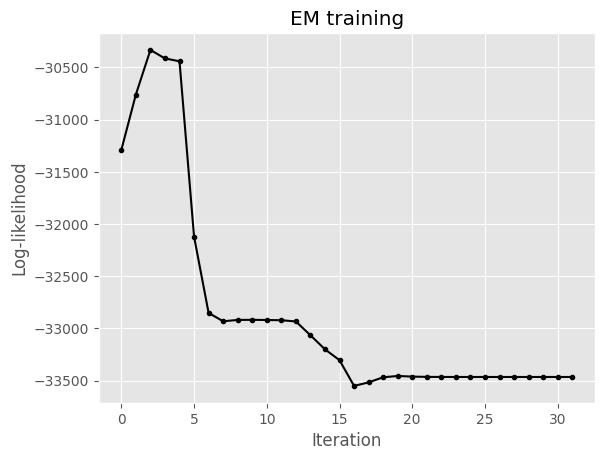

In [69]:
reg_coef = 5e-1
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X,
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    seed=seed,
    allow_singular=False,
)

In [70]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[ 5.24028308e+03,  8.33318158e+03,  1.83797151e+02,
          1.83276951e+00,  3.76254122e-01,  3.57990262e-01,
          7.56512468e+03,  7.56575856e-01,  7.47092262e-01,
         -1.10718464e+00, -1.13750768e+00,  7.12772498e-01,
          7.19405906e-01,  9.79546678e+00,  9.77087019e+00,
          9.72181773e+00,  9.76783488e+00,  9.18985755e+00,
         -1.57178636e-02, -3.81593997e-02, -2.28703500e-05,
          7.81298098e-06,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  9.77442854e-01,
          1.53073600e+01,  8.85979684e-02, -9.34877716e-03,
         -8.20709933e-04, -2.62779699e+02, -3.05598968e-02],
        [ 2.67442576e+03,  5.18765559e+03,  3.54443518e+01,
          8.66669227e-02,  1.61031773e-01,  6.16768288e-02,
          2.31024141e+03,  8.63971387e-01,  8.62298355e-01,
          9.28334269e-01,  9.29777015e-01,  1.19232710e-01,
          1.19232707e-01,  2.89508076e+00,  2.88237376e+00,
          3.53372456e+00,  3.53796076e+

In [71]:
# np.round(gmm.means_), np.round(gmm.covariances_)

In [72]:
y_cls_win, clust_labels_pred

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [73]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)

Silhouette: 0.04213163123785045
Completeness: 0.29498547928684166
Fowlkes-Mallows index: 0.5403795731650664
Homogeneity: 0.09553569920786173
Mutual Information: 0.10495258961043213
Adjusted mutual information: 0.14016936853982692
Normalized Mutual Information: 0.14432837741841884
Rand index: 0.40986289608542836
Adjusted rand index: 0.02997022691388837
V-measure: 0.14432837741841886


In [74]:
# uncertainty = 1 - gamma_resp.max(axis=1)

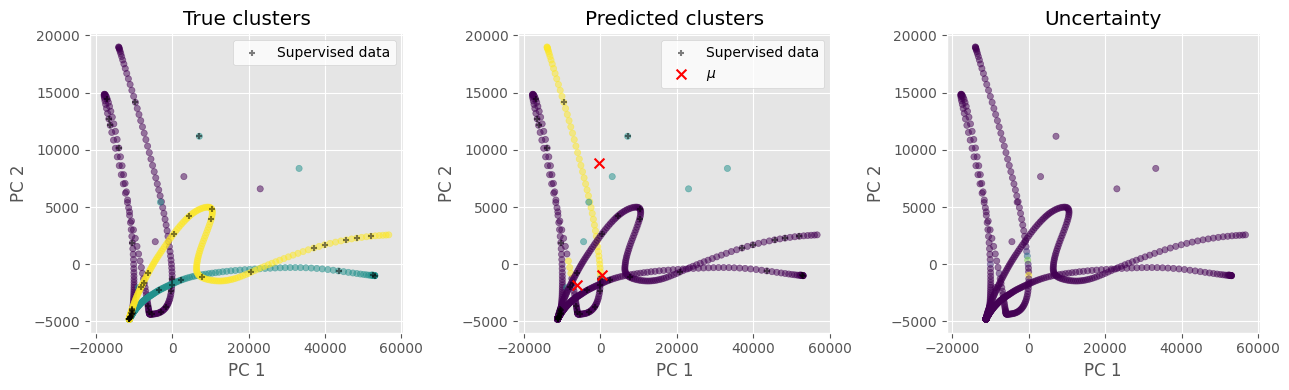

In [75]:
plot_cluster_res(
    U=feat_mat,
    X=X,
    Y=Y,
    labels_gt=y_cls_win,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

## Synthetic hierarchical (toy) data

In [76]:
# def plot_gaussian_hmm(
#     hmm, params, emissions, states, title="Emission Distributions", alpha=0.25
# ):
#     lim = 1.1 * abs(emissions).max()
#     XX, YY = jnp.meshgrid(jnp.linspace(-lim, lim, 100), jnp.linspace(-lim, lim, 100))
#     grid = jnp.column_stack((XX.ravel(), YY.ravel()))

#     plt.figure()
#     for k in range(hmm.num_states):
#         lls = hmm.emission_distribution(params, k).log_prob(grid)
#         plt.contour(
#             XX, YY, jnp.exp(lls).reshape(XX.shape), cmap=white_to_color_cmap(COLORS[k])
#         )
#         plt.plot(
#             emissions[states == k, 0],
#             emissions[states == k, 1],
#             "o",
#             mfc=COLORS[k],
#             mec="none",
#             ms=3,
#             alpha=alpha,
#         )

#     plt.plot(emissions[:, 0], emissions[:, 1], "-k", lw=1, alpha=alpha)
#     plt.xlabel("$y_1$")
#     plt.ylabel("$y_2$")
#     plt.title(title)
#     plt.gca().set_aspect(1.0)
#     plt.tight_layout()

In [77]:
def generate_two_level_hmm_sequence(
    seq_length,
    n_meta,
    n_sub,
    obs_dim,
    A_meta,
    A_sub,
    pi_meta,
    pi_sub,
    means,
    covariances,
    seed=None,
):
    """
    Generate sequence from a 2-level HMM.

    Parameters:
    - A_meta: (n_meta, n_meta) meta-state transition matrix
    - A_sub: (n_meta, n_sub, n_sub) sub-state transition (depends on meta)
    - pi_meta: (n_meta,) initial meta distribution
    - pi_sub: (n_meta, n_sub) initial sub distribution given meta
    - means: (n_meta, n_sub) observation means
    - covariances: (n_meta, n_sub, obs_dim, obs_dim) covariance matrices
    """
    rng = np.random.default_rng(seed)

    # Initialize arrays
    meta_states = np.zeros(seq_length, dtype=int)
    sub_states = np.zeros(seq_length, dtype=int)
    observations = np.zeros((seq_length, obs_dim))

    # Sample initial states
    meta_states[0] = rng.choice(n_meta, p=pi_meta)
    sub_states[0] = rng.choice(n_sub, p=pi_sub[meta_states[0]])

    # Generate first observation (multi-dimensional)
    observations[0] = rng.multivariate_normal(
        mean=means[meta_states[0], sub_states[0]],
        cov=covariances[meta_states[0], sub_states[0]],
    )

    # Generate rest of the sequence
    for t in range(1, seq_length):
        # Meta-state transition (depends only on previous meta)
        meta_states[t] = rng.choice(n_meta, p=A_meta[meta_states[t - 1]])

        # Check if meta-state changed
        if meta_states[t] != meta_states[t - 1]:
            # RESET: Sample sub-state from initial distribution
            sub_states[t] = rng.choice(n_sub, p=pi_sub[meta_states[t]])
        else:
            # Normal transition within same meta-state
            sub_states[t] = rng.choice(
                n_sub, p=A_sub[meta_states[t], sub_states[t - 1]]
            )

        # Multi-dimensional observation (depends on current meta and sub)
        observations[t] = rng.multivariate_normal(
            mean=means[meta_states[t], sub_states[t]],
            cov=covariances[meta_states[t], sub_states[t]],
            # size=(obs_dim),
        )

    return meta_states, sub_states, observations

In [78]:
n_meta = 3
n_sub = 4
obs_dim = 5

# Transition matrices
A_meta = np.array(
    [
        [0.8, 0.1, 0.1],  # from meta 0
        [0.1, 0.8, 0.1],  # from meta 1
        [0.1, 0.1, 0.8],  # from meta 2
    ]
)

# Sub-state transitions for each meta-state
A_sub = np.zeros((n_meta, n_sub, n_sub))
# Meta 0: tends to stay in same sub-state
A_sub[0] = np.array(
    [
        [0.7, 0.1, 0.1, 0.1],
        [0.1, 0.7, 0.1, 0.1],
        [0.1, 0.1, 0.7, 0.1],
        [0.1, 0.1, 0.1, 0.7],
    ]
)
# Meta 1: tends to increase sub-state
A_sub[1] = np.array(
    [
        [0.4, 0.6, 0.0, 0.0],
        [0.0, 0.4, 0.6, 0.0],
        [0.0, 0.0, 0.4, 0.6],
        [0.6, 0.0, 0.0, 0.4],
    ]
)
# Meta 2: tends to decrease sub-state
# A_sub[2] = np.array(
#     [
#         [0.4, 0.0, 0.0, 0.6],
#         [0.6, 0.4, 0.0, 0.0],
#         [0.0, 0.6, 0.4, 0.0],
#         [0.0, 0.0, 0.6, 0.4],
#     ]
# )
# Meta 2: tends to increase sub-state
A_sub[2] = np.array(
    [
        [0.4, 0.6, 0.0, 0.0],
        [0.0, 0.4, 0.6, 0.0],
        [0.0, 0.0, 0.4, 0.6],
        [0.6, 0.0, 0.0, 0.4],
    ]
)

# Initial distributions
pi_meta = np.array([0.34, 0.33, 0.33])  # uniform-ish
# pi_sub = np.array(
#     [
#         [0.4, 0.3, 0.2, 0.1],  # given meta 0
#         [0.1, 0.2, 0.3, 0.4],  # given meta 1
#         [0.25, 0.25, 0.25, 0.25],  # given meta 2
#     ]
# )
pi_sub = np.array(
    [
        [0.6, 0.1, 0.2, 0.1],  # given meta 0
        [0.2, 0.6, 0.1, 0.1],  # given meta 1
        [0.0, 0.2, 0.6, 0.2],  # given meta 2
    ]
)


# Multi-dimensional observation parameters
means = np.zeros((n_meta, n_sub, obs_dim))
covariances = np.zeros((n_meta, n_sub, obs_dim, obs_dim))

# # Make means distinct for different meta-sub combinations
# for m in range(n_meta):
#     for s in range(n_sub):
#         means[m, s] = m * 10 + s * 2  # e.g., meta0: 0,2,4,6; meta1: 10,12,14,16; etc.

# Define different (meta, sub) pairs to have distinct 2D Gaussian distributions
for m in range(n_meta):
    for s in range(n_sub):
        # Different centers for each state
        means[m, s, :] = [
            m * 10 + s * 2,
            m * 5 + s * 1.5,
            m * 15 + s * 2.5,
            m * 20 + s * 1,
            m * 0 + s * 0,
        ]

        # Different covariance structures
        if m == 0:  # Meta 0: isotropic
            covariances[m, s] = np.eye(obs_dim) * (s + 1)
        elif m == 1:  # Meta 1: correlated
            # covariances[m, s] = np.array([[2.0, 0.8], [0.8, 1.0]]) * (s + 1)
            covariances[m, s] = np.array(
                [
                    [3.0, 0.8, 0.8, 0.0, 0.0],
                    [0.8, 3.0, 0.8, 0.0, 0.0],
                    [0.0, 0.8, 2.0, 0.8, 0.0],
                    [0.0, 0.0, 0.8, 2.0, 0.8],
                    [0.0, 0.0, 0.8, 0.8, 2.0],
                ]
            ) * (s + 1)
        else:  # Meta 2: anti-correlated
            # covariances[m, s] = np.array([[2.0, -0.5], [-0.5, 1.0]]) * (s + 1)
            covariances[m, s] = np.array(
                [
                    [2.0, -0.5, -0.5, 0.0, 0.0],
                    [-0.5, 2.0, -0.5, 0.0, 0.0],
                    [0.0, -0.5, 1.0, -0.5, 0.0],
                    [0.0, 0.0, -0.5, 1.0, -0.5],
                    [0.0, 0.0, -0.5, -0.5, 1.0],
                ]
            ) * (s + 1)
        covariances[m, s] = 1 / 2 * (covariances[m, s] + covariances[m, s].T)

In [79]:
# covariances

In [80]:
# Generate sequence
meta_states, sub_states, observations = generate_two_level_hmm_sequence(
    seq_length=seq_length,
    n_meta=n_meta,
    n_sub=n_sub,
    obs_dim=obs_dim,
    A_meta=A_meta,
    A_sub=A_sub,
    pi_meta=pi_meta,
    pi_sub=pi_sub,
    means=means,
    covariances=covariances,
    seed=seed,
)

print(f"Meta states:  {meta_states}")
print(f"Sub states:   {sub_states}")
print(f"Observations:\n{np.round(observations[:10, :], 2)}\n [...]")

Meta states:  [2 2 2 2 1 1 1 0 0 0 1 1 1 1 2 2 1 1 1 0 2 0 0 0 0 2 2 2 2 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 2 2 2 1 1 1 1 1 1 1 0 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0
 0 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 1 1 0 0 0 0 0 0 1 1 1 0
 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 1 1 1 1 0 0 0 0 0 0 0 0 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 0 2 1 1 1 1 1 2 2
 2 2 2 2 2 2 1 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 2
 2 2 2 2 2 2 1 2 0 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 2 2 2 2
 2 2 2 2 2 2 2 2 2 1 1 0 0 0 0 2 2 2 1 1 2 2 2 2 2 2 0 0 2 0 0 2 2 0 0 0 0
 2 0 0 0 0 0 0 0 0 0 1 1 1 1 1 2 2 0 1 1 1 2 0 0 0 0 0 0 0 0 2 2 1 1 1 1 0
 0 0 0 0 0 1 1 1 2 2 2 2 2 2 2 0 0 0 1 0 0 0 2 0 0 0 0 0 0 1 0 1 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 2 1 1 1 1 1
 1 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2
 1 1 1 1 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 1 1 1 1 1 0 0 0 0 0 2 2 2 2 2 2
 2 2 2 2 0 

In [81]:
observations.shape

(1000, 5)

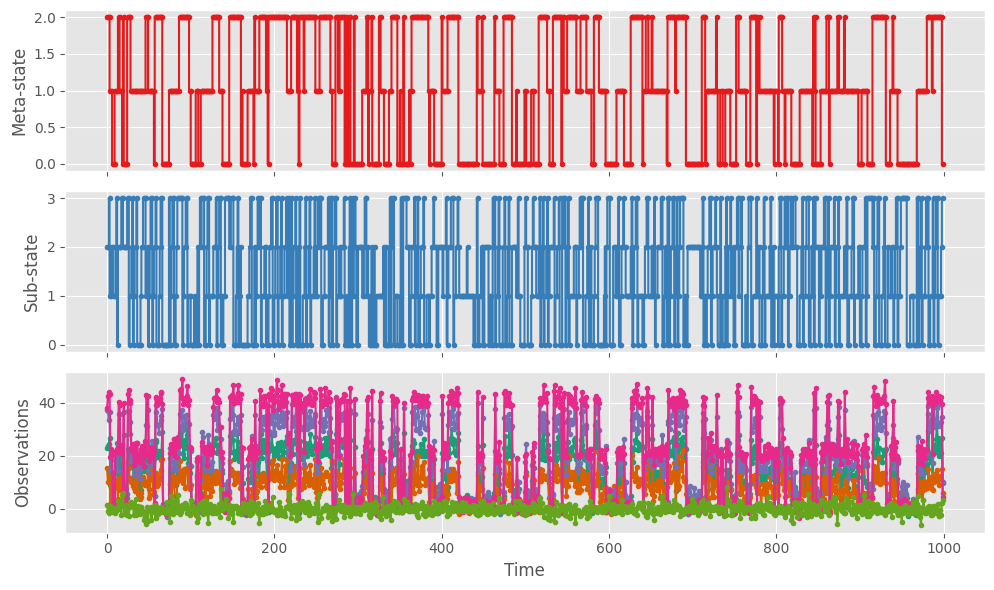

In [82]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["Set1"].colors
    cmap2 = plt.colormaps["Dark2"].colors
    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 6))
    axes[0].step(meta_states, ".-", c=cmap[0])
    axes[0].set_ylabel("Meta-state")
    axes[1].step(sub_states, ".-", c=cmap[1])
    axes[1].set_ylabel("Sub-state")
    for obsi in range(obs_dim):
        axes[2].plot(observations[:, obsi], ".-", c=cmap2[obsi])  # , c=cmap[2])
    axes[2].set_ylabel("Observations")
    axes[2].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

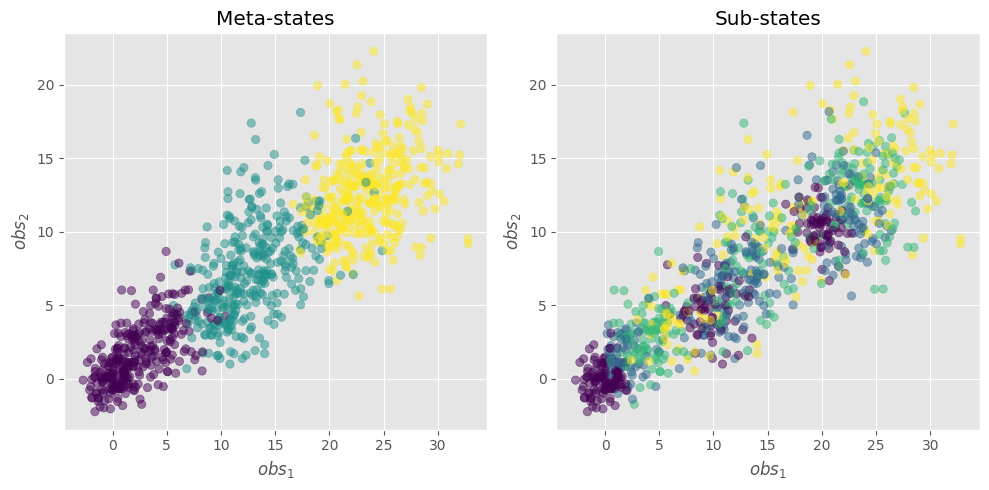

In [83]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    ax[0].scatter(observations[:, 0], observations[:, 1], alpha=0.5, c=meta_states)
    ax[1].scatter(observations[:, 0], observations[:, 1], alpha=0.5, c=sub_states)
    ax[0].set_title("Meta-states")
    ax[1].set_title("Sub-states")
    for axi in ax:
        axi.set_xlabel(f"$obs_1$")
        axi.set_ylabel(f"$obs_2$")
    fig.tight_layout()
    plt.show()

In [84]:
windows = sliding_window(series=observations, window_size=window_size, step=window_step)
windows.shape

(197, 20, 5)

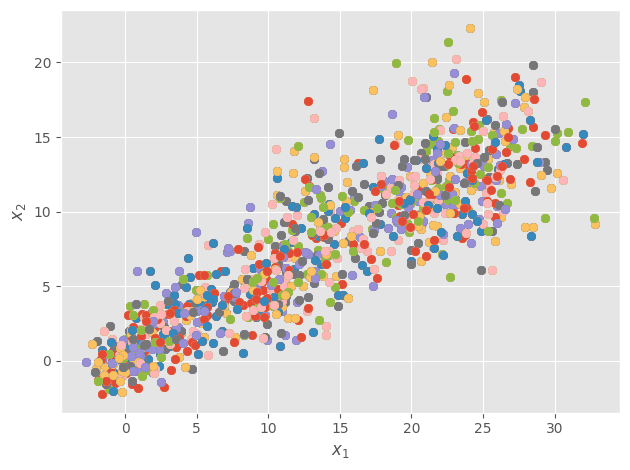

In [85]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        ax.scatter(windows[idx, :, 0], windows[idx, :, 1])  # , color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

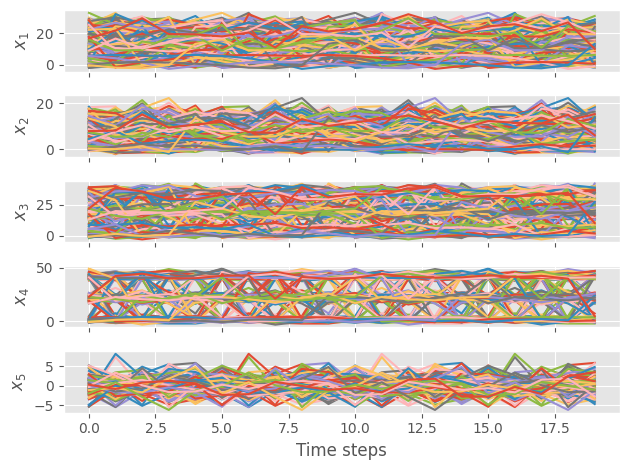

In [86]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[0]):
            ax[idx].plot(windows[jdx, :, idx])  # , c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [87]:
feat_mat = extract_features(windows)
feat_mat.shape

(197, 69)

In [88]:
for col in range(feat_mat.shape[1]):
    if np.any(np.isnan(feat_mat[:, col])):
        feat_mat = np.delete(arr=feat_mat, obj=col, axis=1)
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,59,60,61,62,63,64,65,66,67,68
0,5309.710880,1715.018059,11995.584216,15009.528201,99.346315,926.786575,0.763659,0.953137,0.790478,0.812107,...,1.0,18.474087,0.457070,-0.044619,-0.243340,-0.238790,-0.114295,1.016047,-63.086589,0.898502
1,3737.859604,1061.485940,8046.610227,9164.488927,103.868960,702.664741,1.956361,0.921991,0.740627,0.815052,...,1.0,14.870882,0.596520,0.603298,-0.147804,0.314613,0.256456,0.998356,2062.489192,1.041180
2,5512.416626,1830.360341,12112.166002,15990.933899,116.742594,952.718338,1.540105,0.953048,0.821130,0.594904,...,1.0,18.858054,0.655690,-0.089075,0.133048,-0.106546,-0.245232,0.535868,768.821665,0.903935
3,5230.394457,1825.601860,11051.883604,14817.065776,132.659682,898.645211,2.187019,0.951371,0.816080,0.637961,...,1.0,18.181751,0.600253,0.019980,0.166791,0.054384,-0.131839,0.340255,1300.382054,0.900477
4,4749.216609,1953.930971,9733.344807,13813.028578,65.516572,879.352565,2.124440,0.846356,0.869614,0.915605,...,1.0,17.411214,0.591098,0.322749,0.366168,0.334436,-0.029713,0.137564,-3563.590573,0.916103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,2196.937346,788.434386,4259.457074,4980.849323,110.863345,505.370977,2.588596,0.859814,0.822700,0.929922,...,1.0,11.106998,0.597133,0.112078,0.431875,0.048027,-0.123832,-0.092916,1791.462615,1.241863
193,4533.956380,1337.503964,9222.615043,12387.687196,103.509247,855.536807,2.312388,0.913173,0.626916,0.898348,...,1.0,16.608814,0.632111,-0.389449,-0.272109,-0.281125,-0.007842,-0.186465,4817.144839,1.000460
194,6229.833678,1664.356310,13540.368743,19102.265375,85.397293,1169.870397,3.736903,0.911543,0.433654,0.893144,...,1.0,20.154955,0.659995,0.238076,0.430188,0.414437,0.369376,-0.751364,9828.708250,0.799007
195,8513.728249,2152.651264,17902.527023,25324.540399,48.332280,1366.002129,4.031186,0.923258,0.633167,0.538723,...,1.0,23.225370,0.407586,0.086114,-0.137379,-0.434118,-0.679884,0.323317,8414.313915,0.761079


In [89]:
feat_mat = pd.DataFrame(observations)
feat_mat

,0,1,2,3,4
0,22.940814,15.556814,37.197462,37.966697,1.637203
1,23.811693,10.079408,36.853285,42.682567,-0.740727
2,24.425144,14.285568,33.523082,43.963736,-1.384405
3,26.930447,14.382339,36.462963,43.223479,1.238360
4,8.872408,1.733691,14.711358,19.505542,1.071051
...,...,...,...,...,...
995,24.237979,12.256451,32.199589,42.779120,-2.844023
996,25.554040,11.458841,31.978587,41.215469,-0.361637
997,21.210384,11.196512,32.821307,42.204824,-2.151652
998,26.746277,15.016296,34.539892,39.576474,2.386507


### Meta-states clustering

In [90]:
K_components = n_meta

In [91]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=meta_states, window_size=window_size, step=window_step),
        axis=1,
    )
).astype(int)
y_cls_win

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
       2, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1,
       1, 2, 2, 2, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2])

In [92]:
# supervised_sample_size = 20
# idx_superv = np.random.choice(
#     np.arange(y_cls_win.shape[0]), size=supervised_sample_size, replace=False
# )
# Y = np.zeros((len(idx_superv), K_components))
# for idxi, idx_val in enumerate(idx_superv):
#     Y[idxi, int(y_cls_win[int(idx_val)])] = 1
# # Y = labels_gt[idx_superv]
# X = feat_mat.iloc[idx_superv, :]
# X.shape, Y

In [93]:
supervised_sample_size = 15
X, Y = select_supervised_data(
    total_sample_size=supervised_sample_size,
    labels_gt=y_cls_win,
    K_components=K_components,
    U=feat_mat.to_numpy(),
)
X.shape, Y

((15, 5),
 array([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.]]))

Iteration 0/300 -- Log-likelihood: -8057.781989467627

--- Converged at iteration 7 ---



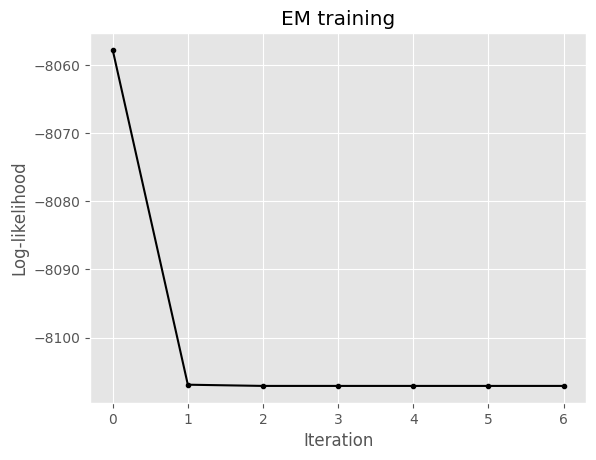

In [94]:
reg_coef = 1e-2
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X,
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    seed=seed,
    allow_singular=False,
)

In [95]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[12.97304958,  7.43411268, 18.96966237, 21.58874425,  0.06734902],
        [ 2.40283768,  1.70810153,  3.07870773,  1.15029019,  0.11582497],
        [23.36303195, 12.51941322, 33.95585138, 41.47492615, -0.19922258]]),
 array([[[11.7880913 ,  0.        ,  0.        ,  0.        ,
           0.        ],
         [ 0.        , 10.20754001,  0.        ,  0.        ,
           0.        ],
         [ 0.        ,  0.        , 13.59206329,  0.        ,
           0.        ],
         [ 0.        ,  0.        ,  0.        ,  5.44731749,
           0.        ],
         [ 0.        ,  0.        ,  0.        ,  0.        ,
           4.94256169]],
 
        [[17.88463743,  0.        ,  0.        ,  0.        ,
           0.        ],
         [ 0.        ,  7.02808284,  0.        ,  0.        ,
           0.        ],
         [ 0.        ,  0.        , 32.46750846,  0.        ,
           0.        ],
         [ 0.        ,  0.        ,  0.        , 37.75053934,
           0.       

In [96]:
y_cls_win, clust_labels_pred

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
        2, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1,
        1, 2, 2, 2, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2]),
 array([2, 2, 2, 2, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 2, 2, 0, 0, 0, 1, 2, 1,
        1, 1, 1, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2

In [97]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)

Silhouette: 0.7083008926282173


ValueError: Found input variables with inconsistent numbers of samples: [197, 1000]

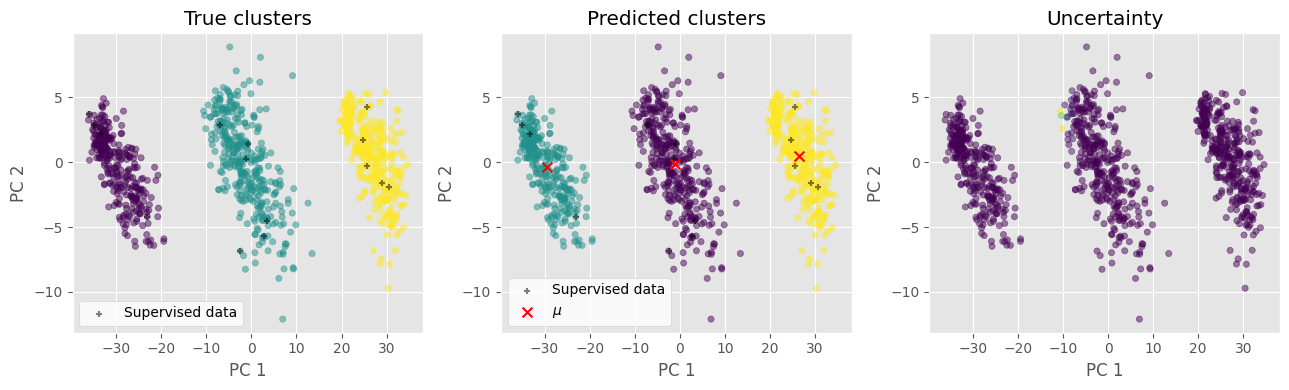

In [98]:
plot_cluster_res(
    U=feat_mat,
    X=X,
    Y=Y,
    # labels_gt=y_cls_win,
    labels_gt=meta_states,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

### Sub-states clustering

In [99]:
K_components = n_sub

In [100]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=sub_states, window_size=window_size, step=window_step),
        axis=1,
    )
).astype(int)
y_cls_win

array([2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 2, 2, 1, 1, 1,
       1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 2, 1, 2,
       2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1,
       1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2])

In [101]:
supervised_sample_size = 30
idx_superv = np.random.choice(
    np.arange(y_cls_win.shape[0]), size=supervised_sample_size, replace=False
)
Y = np.zeros((len(idx_superv), K_components))
for idxi, idx_val in enumerate(idx_superv):
    Y[idxi, int(y_cls_win[int(idx_val)])] = 1
# Y = labels_gt[idx_superv]
X = feat_mat.iloc[idx_superv, :]
X.shape, Y

((30, 5),
 array([[0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.]]))

Iteration 0/300 -- Log-likelihood: -9497.774002372957
Iteration 10/300 -- Log-likelihood: -9509.642014081113
Iteration 20/300 -- Log-likelihood: -9509.381714262783
Iteration 30/300 -- Log-likelihood: -11996.994753363078
Iteration 40/300 -- Log-likelihood: -11945.189023407533
Iteration 50/300 -- Log-likelihood: -14005.202640854313
Iteration 60/300 -- Log-likelihood: -13587.003935967361
Iteration 70/300 -- Log-likelihood: -9731.499648726789
Iteration 80/300 -- Log-likelihood: -10515.17135303104
Iteration 90/300 -- Log-likelihood: -9541.630965894674
Iteration 100/300 -- Log-likelihood: -9523.565273987155
Iteration 110/300 -- Log-likelihood: -9505.08761615731
Iteration 120/300 -- Log-likelihood: -12033.755375592704
Iteration 130/300 -- Log-likelihood: -12053.519314985304
Iteration 140/300 -- Log-likelihood: -13944.54225344184
Iteration 150/300 -- Log-likelihood: -13925.28833813706
Iteration 160/300 -- Log-likelihood: -9610.868663894958
Iteration 170/300 -- Log-likelihood: -9705.55683136957

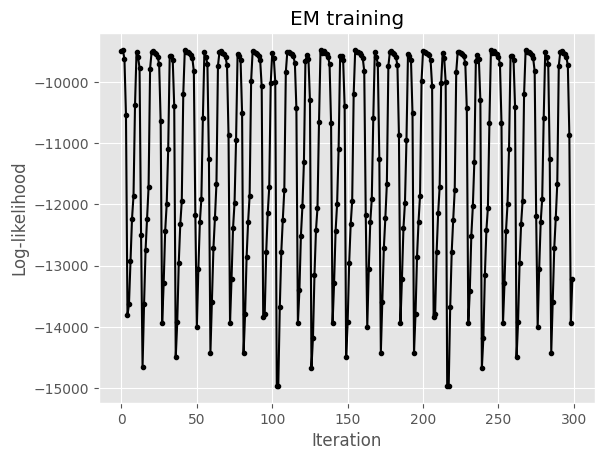

In [102]:
reg_coef = 1e-2
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X.to_numpy(),
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    seed=seed,
    allow_singular=False,
)

In [103]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[13.37266802,  7.7357876 , 19.55634671, 22.17488004,  0.07806314],
        [ 5.06042089,  3.38167774,  6.53435157,  3.94422217,  0.08638598],
        [ 1.74339137,  1.1579758 ,  2.29801107,  1.28356201,  0.15931381],
        [24.02684452, 12.87911286, 34.8983662 , 42.66721756, -0.19267385]]),
 array([[[ 11.94080405,   0.        ,   0.        ,   0.        ,
            0.        ],
         [  0.        ,  10.30964598,   0.        ,   0.        ,
            0.        ],
         [  0.        ,   0.        ,  13.82623591,   0.        ,
            0.        ],
         [  0.        ,   0.        ,   0.        ,   5.81808593,
            0.        ],
         [  0.        ,   0.        ,   0.        ,   0.        ,
            5.05191965]],
 
        [[ 65.75797105,   0.        ,   0.        ,   0.        ,
            0.        ],
         [  0.        ,  19.20606163,   0.        ,   0.        ,
            0.        ],
         [  0.        ,   0.        , 131.17904286,   0.  

In [104]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)

Silhouette: 0.5781370594020293


ValueError: Found input variables with inconsistent numbers of samples: [197, 1000]

In [105]:
plot_cluster_res(
    U=feat_mat,
    X=X,
    Y=Y,
    labels_gt=y_cls_win,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

ValueError: 'c' argument has 197 elements, which is inconsistent with 'x' and 'y' with size 1000.